# Radiosonde Atmosphere Generator

In this notebook, we'll use pyRadtran's `RadiosondeAtmosphereGenerator` to download radiosonde profiles from the IGRA database and convert them into atmosphere files compatible with libRadtran. This allows us to run simulations with realistic, observation-based atmospheric profiles.

## How It Works

The generator:

1. Downloads the global [IGRA v2](https://www.ncei.noaa.gov/products/weather-balloon/integrated-global-radiosonde-archive) station list from NOAA/NCEI
2. Finds the closest **active** radiosonde stations to your target location using the Haversine formula
3. Queries the IGRA database (via the [Siphon](https://unidata.github.io/siphon/) library) for the nearest available sounding in time
4. Converts the sounding (pressure, temperature, dewpoint) into a libRadtran `radiosonde` atmosphere file

The output file contains columns: `p (hPa)`, `T (K)`, `H₂O (RH %)`, sorted from top-of-atmosphere to surface.

```{note}
Retrieving radiosonde data from the IGRA database can take 3–5 minutes. IGRA data availability typically lags by a few weeks to months. If you get an `InputGenerationError` saying no data was found, try an older date.
```

## Requirements

The radiosonde generator requires the **siphon** package, which is an **optional** dependency of pyRadtran:

```bash
pip install siphon
# or
conda install -c conda-forge siphon
# or
micromamba install siphon
```

In [1]:
# Check that siphon is installed
try:
    from siphon.simplewebservice.igra2 import IGRAUpperAir
    print("siphon is available ✓")
except ImportError:
    raise ImportError(
        "siphon is required for the radiosonde generator. "
        "Install it with: pip install siphon"
    )

# Set up logging
import logging
logging.basicConfig(level=logging.INFO)
logging.getLogger("pyradtran").setLevel(logging.INFO)

siphon is available ✓


## Example 1: One-Step Atmosphere File Generation

The simplest way to get a radiosonde atmosphere file is with `RadiosondeAtmosphereGenerator.create_radiosonde_atmosphere_file()`. You provide a target time and location — the generator finds the closest station and sounding automatically.

In [2]:
from datetime import datetime
from pathlib import Path
from pyradtran.io import RadiosondeAtmosphereGenerator

# Target: Ny-Ålesund, Svalbard
lat, lon = 78.925, 11.922

# Create the atmosphere file in one step
atm_path = RadiosondeAtmosphereGenerator.create_radiosonde_atmosphere_file(
    time=datetime(2024, 6, 7, 12),  # use a date that is well in the past for IGRA availability
    latitude=lat,
    longitude=lon,
    output_filepath="work/sonde_nya.dat",
)

print(f"Atmosphere file created at: {atm_path}")

INFO:pyradtran.io:Found sounding for BJORNOYA at 2024-06-07 12:00:00 UTC with distance 521.61 km


INFO:pyradtran.io:Created radiosonde atmosphere file: work/sonde_nya.dat


Atmosphere file created at: work/sonde_nya.dat


### Inspect the Generated File

The output is a simple text file that libRadtran reads directly via the `radiosonde` input option. Each row is one pressure level with pressure (hPa), temperature (K) and relative humidity (%).

In [3]:
# Inspect the generated atmosphere file
print(Path("work/sonde_nya.dat").read_text())

# Radiosonde atmosphere profile
# BJORNOYA at 2024-06-07 12:00 UTC with distance 521.61 km
# p(hPa)  T(K)  h2o(RH%)
10.49  238.75  0.471
10.60  238.15  0.469
11.34  236.95  0.466
11.51  236.55  0.463
11.93  235.35  0.460
12.64  233.75  0.461
12.85  233.65  0.465
13.44  233.45  0.460
14.17  232.75  0.463
16.15  231.25  0.483
17.15  230.75  0.518
17.63  231.05  0.502
18.76  230.05  0.481
19.18  229.25  0.533
20.00  228.75  0.517
22.65  226.85  0.606
24.97  228.25  0.565
27.51  227.55  0.561
29.17  226.55  0.616
30.00  226.65  0.609
31.98  226.35  0.651
34.20  226.65  0.619
37.73  226.75  0.633
40.72  226.15  0.633
42.60  225.35  0.669
43.85  225.65  0.681
44.95  226.45  0.666
47.76  226.55  0.659
50.00  226.65  0.640
54.17  225.85  0.666
56.99  224.95  0.688
58.42  224.45  0.741
59.70  224.65  0.749
67.49  225.45  0.720
68.85  225.45  0.720
70.00  225.05  0.704
71.29  224.25  0.771
71.89  224.05  0.775
78.13  224.85  0.783
81.60  225.85  0.761
86.94  226.15  0.700
96.62  226.75  0.700
10

## Example 2: Step-by-Step — Station Search and Data Retrieval

If you need more control, you can use the individual static methods to find stations and retrieve soundings separately.

In [4]:
# Step 1: Get the global IGRA station list
stations = RadiosondeAtmosphereGenerator.get_station_list()
print(f"Total IGRA stations: {len(stations)}")
stations.head()

Total IGRA stations: 2923


,id,latitude,longitude,elevation,state,name,first_year,last_year,num_obs
0,ACM00078861,17.1170,-61.7830,10.0,NaN,COOLIDGE FIELD (UA),1947,1993,13896
1,AEM00041217,24.4333,54.6500,16.0,NaN,ABU DHABI INTERNATIONAL AIRPOR,1983,2026,41254
2,AEXUAE05467,25.2500,55.3700,4.0,NaN,SHARJAH,1935,1942,2477
3,AFM00040911,36.7000,67.2000,378.0,NaN,MAZAR-I-SHARIF,2010,2014,2179
4,AFM00040913,36.6667,68.9167,433.0,NaN,KUNDUZ,2010,2013,4540


In [5]:
# Step 2: Find the 5 closest active stations to Ny-Ålesund
closest = RadiosondeAtmosphereGenerator.find_closest_active_stations(stations, lat, lon, n=5)
closest[['id', 'name', 'latitude', 'longitude', 'distance_km']]

,id,name,latitude,longitude,distance_km
1993,SVM00001004,NY-ALESUND II,78.9233,11.9222,0.189080
1994,SVM00001028,BJORNOYA,74.5167,19.0047,521.610006
860,GLM00004320,DANMARKSHAVN,76.7694,-18.6681,744.833867
1725,RSM00020046,POLARGMO IM. E.T. KRENKELJA,80.6264,58.0589,903.903991
1241,JNM00001001,JAN MAYEN,70.9331,-8.6667,1056.578900


In [6]:
# Step 3: Retrieve the closest sounding
# Enable debug logging to see station-by-station search progress
logging.getLogger("pyradtran").setLevel(logging.DEBUG)

sounding_df, header, header_text = RadiosondeAtmosphereGenerator.get_closest_sounding(
    target_dt=datetime(2024, 6, 7, 12),
    lat=lat,
    lon=lon,
)

print(f"Station: {header_text}")
print(f"Sounding levels: {len(sounding_df)}")
sounding_df.head(10)

DEBUG:pyradtran.io:Trying station NY-ALESUND II (SVM00001004) at 2024-06-07 12:00:00


DEBUG:pyradtran.io:No data for NY-ALESUND II at 2024-06-07 12:00:00: No dates match selection. This selection has data from 1992-10-06 12:00:00 to 1992-10-06 12:00:00.


DEBUG:pyradtran.io:Trying station NY-ALESUND II (SVM00001004) at 2024-06-07 00:00:00


DEBUG:pyradtran.io:No data for NY-ALESUND II at 2024-06-07 00:00:00: No dates match selection. This selection has data from 1992-10-06 12:00:00 to 1992-10-06 12:00:00.


DEBUG:pyradtran.io:Trying station NY-ALESUND II (SVM00001004) at 2024-06-06 12:00:00


...

DEBUG:pyradtran.io:No data for NY-ALESUND II at 2024-06-06 00:00:00: No dates match selection. This selection has data from 1992-10-06 12:00:00 to 1992-10-06 12:00:00.


DEBUG:pyradtran.io:Trying station BJORNOYA (SVM00001028) at 2024-06-07 12:00:00


INFO:pyradtran.io:Found sounding for BJORNOYA at 2024-06-07 12:00:00 UTC with distance 521.61 km


Station: BJORNOYA at 2024-06-07 12:00 UTC with distance 521.61 km
Sounding levels: 119


,lvltyp1,lvltyp2,etime,pressure,pflag,height,zflag,temperature,tflag,relative_humidity,direction,speed,date,u_wind,v_wind,dewpoint
0,2,1,0,1011.60,2,20,0,2.8,2,NaN,82,10.0,2024-06-07 12:00:00,-9.9,-1.4,2.0
1,1,0,16,1000.00,0,113,2,1.3,2,NaN,86,11.9,2024-06-07 12:00:00,-11.9,-0.8,1.3
2,2,0,52,979.73,0,278,2,0.2,2,NaN,98,17.7,2024-06-07 12:00:00,-17.5,2.5,0.2
3,2,0,78,968.07,0,374,2,3.8,2,NaN,114,18.6,2024-06-07 12:00:00,-17.0,7.6,-0.3
4,2,0,92,961.94,0,426,2,6.3,2,NaN,111,17.9,2024-06-07 12:00:00,-16.7,6.4,-1.3
5,2,0,174,927.70,0,725,2,8.0,2,NaN,105,17.1,2024-06-07 12:00:00,-16.5,4.4,-2.1
6,1,0,181,925.00,0,749,2,7.9,2,NaN,104,17.4,2024-06-07 12:00:00,-16.9,4.2,-1.7
7,2,0,214,909.02,0,892,2,7.0,2,NaN,101,17.0,2024-06-07 12:00:00,-16.7,3.2,0.5
8,2,0,262,888.20,0,1082,2,6.3,2,NaN,107,15.2,2024-06-07 12:00:00,-14.5,4.4,3.5
9,1,0,352,850.00,0,1443,2,6.2,2,NaN,109,10.6,2024-06-07 12:00:00,-10.0,3.5,-12.5


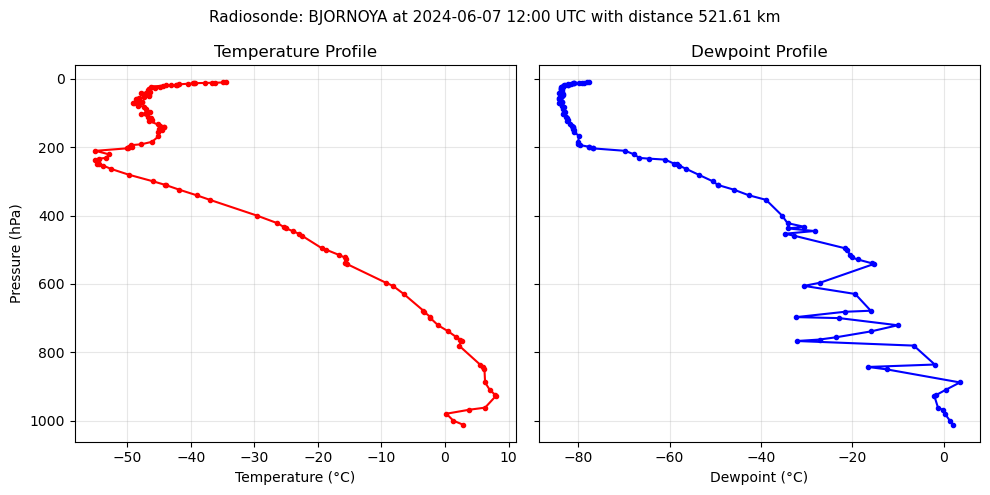

In [7]:
# Quick plot of the sounding profile
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

axes[0].plot(sounding_df['temperature'], sounding_df['pressure'], 'r-o', markersize=3)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Pressure (hPa)')
axes[0].invert_yaxis()
axes[0].set_title('Temperature Profile')
axes[0].grid(alpha=0.3)

axes[1].plot(sounding_df['dewpoint'], sounding_df['pressure'], 'b-o', markersize=3)
axes[1].set_xlabel('Dewpoint (°C)')
axes[1].set_title('Dewpoint Profile')
axes[1].grid(alpha=0.3)

fig.suptitle(f'Radiosonde: {header_text}', fontsize=11)
plt.tight_layout()

## Using the Atmosphere File with PyRadtran

Once you have the atmosphere file, pass it to a simulation via `params`:

```python
ds_sim = ds.pyradtran.run(
    config_path="config/my_config.yaml",
    return_dataset=True,
    params={"radiosonde": "work/sonde_nya.dat H2O RH"},
)
```

The `H2O RH` suffix tells libRadtran that the water vapour column is in relative humidity (%). See the [libRadtran documentation](http://www.libradtran.org/doku.php) for other supported formats (e.g., `H2O VMR` for volume mixing ratio).

## API Reference

| Method | Description |
|--------|-------------|
| `RadiosondeAtmosphereGenerator.create_radiosonde_atmosphere_file(time, latitude, longitude, output_filepath)` | All-in-one: find station, download sounding, write file |
| `RadiosondeAtmosphereGenerator.get_station_list()` | Download the IGRA v2 station list |
| `RadiosondeAtmosphereGenerator.find_closest_active_stations(stations_df, lat, lon, n=5)` | Find the N nearest active stations |
| `RadiosondeAtmosphereGenerator.get_closest_sounding(target_dt, lat, lon)` | Retrieve the closest sounding as a DataFrame |